# Cross-check: duplicate GitHub repos between datasets

Compares `full_repo_path` URLs in **JSVulnerabilityDataSet-1.0.csv** and **pm_uom_all_full.csv** to find repos (owner/name) that appear in both.

In [1]:
import re
import pandas as pd

PATH_1 = "JSVulnerabilityDataSet-1.0.csv"
PATH_2 = "pm_uom_all_full.csv"

# Only pull the column we need from each ~4-5MB file to keep this light.
df1_raw = pd.read_csv(PATH_1, usecols=["full_repo_path"])
df2_raw = pd.read_csv(PATH_2, usecols=["full_repo_path"])

print(f"{PATH_1}: {len(df1_raw):,} rows")
print(f"{PATH_2}: {len(df2_raw):,} rows")
df1_raw.head(3)

JSVulnerabilityDataSet-1.0.csv: 12,125 rows
pm_uom_all_full.csv: 8,038 rows


,full_repo_path
0,https://github.com/actionhero/actionhero/blob/...
1,https://github.com/actionhero/actionhero/blob/...
2,https://github.com/actionhero/actionhero/blob/...


In [2]:
# full_repo_path looks like:
# https://github.com/{owner}/{repo}/blob/{commit_hash}/{filepath}
REPO_RE = re.compile(r"github\.com/([^/]+/[^/]+)/blob/", re.IGNORECASE)

def extract_repo(url):
    m = REPO_RE.search(str(url))
    return m.group(1) if m else None

df1_raw["repo"] = df1_raw["full_repo_path"].apply(extract_repo)
df2_raw["repo"] = df2_raw["full_repo_path"].apply(extract_repo)

unmatched_1 = df1_raw["repo"].isna().sum()
unmatched_2 = df2_raw["repo"].isna().sum()
if unmatched_1 or unmatched_2:
    print(f"Warning: could not parse a repo from {unmatched_1} rows in dataset 1, "
          f"{unmatched_2} rows in dataset 2 (check full_repo_path format).")

# GitHub owner/repo is case-insensitive, so match on a lowercased key but keep
# a readable original-casing label for display.
df1_raw["repo_key"] = df1_raw["repo"].str.lower()
df2_raw["repo_key"] = df2_raw["repo"].str.lower()

label_1 = df1_raw.dropna(subset=["repo_key"]).drop_duplicates("repo_key").set_index("repo_key")["repo"]
label_2 = df2_raw.dropna(subset=["repo_key"]).drop_duplicates("repo_key").set_index("repo_key")["repo"]

repos1 = set(label_1.index)
repos2 = set(label_2.index)

In [3]:
overlap_keys = repos1 & repos2
only1_keys = repos1 - repos2
only2_keys = repos2 - repos1

print(f"Unique repos in {PATH_1}: {len(repos1)}")
print(f"Unique repos in {PATH_2}: {len(repos2)}")
print(f"Repos in BOTH datasets (duplicates): {len(overlap_keys)}")
print(f"Only in {PATH_1}: {len(only1_keys)}")
print(f"Only in {PATH_2}: {len(only2_keys)}")

Unique repos in JSVulnerabilityDataSet-1.0.csv: 93
Unique repos in pm_uom_all_full.csv: 73
Repos in BOTH datasets (duplicates): 73
Only in JSVulnerabilityDataSet-1.0.csv: 20
Only in pm_uom_all_full.csv: 0


In [4]:
# Row counts per repo in each dataset, so you can see which duplicated repos
# carry the most weight in either file.
counts_1 = df1_raw["repo_key"].value_counts()
counts_2 = df2_raw["repo_key"].value_counts()

overlap_df = pd.DataFrame({
    "repo": [label_1[k] for k in overlap_keys],
    f"rows_in_{PATH_1}": [counts_1[k] for k in overlap_keys],
    f"rows_in_{PATH_2}": [counts_2[k] for k in overlap_keys],
}).sort_values(f"rows_in_{PATH_1}", ascending=False).reset_index(drop=True)

print(f"{len(overlap_df)} repos appear in both datasets:")
overlap_df

73 repos appear in both datasets:


,repo,rows_in_JSVulnerabilityDataSet-1.0.csv,rows_in_pm_uom_all_full.csv
0,c3js/c3,2357,2357
1,mediaelement/mediaelement,2160,1523
2,angular/angular.js,1926,108
3,electron/electron,1058,699
4,textAngular/textAngular,658,658
...,...,...,...
68,jshttp/forwarded,2,2
69,zeit/serve,2,2
70,jonschlinkert/randomatic,1,1
71,Strider-CD/strider-sauce,1,1


In [5]:
# Save the overlap list for reference outside the notebook.
overlap_df.to_csv("duplicate_repos_between_datasets.csv", index=False)
print("Saved duplicate_repos_between_datasets.csv")

Saved duplicate_repos_between_datasets.csv


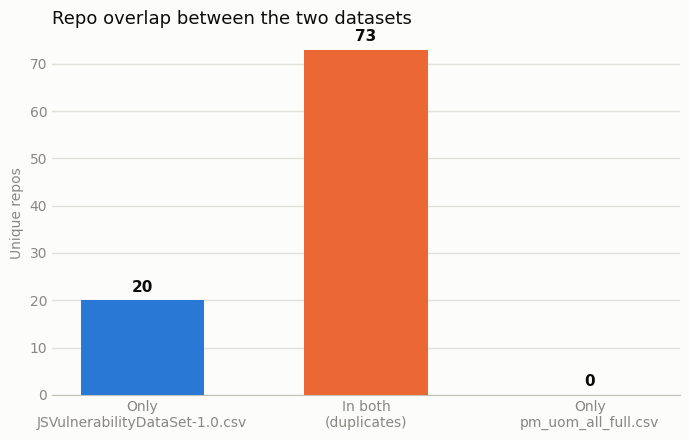

In [6]:
import matplotlib.pyplot as plt

# Categorical hues (light-mode, validated all-pairs for 3 slots): blue, orange, aqua.
CATEGORY_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"

labels = [f"Only\n{PATH_1}", "In both\n(duplicates)", f"Only\n{PATH_2}"]
values = [len(only1_keys), len(overlap_keys), len(only2_keys)]

fig, ax = plt.subplots(figsize=(7, 4.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

bars = ax.bar(labels, values, color=CATEGORY_COLORS, width=0.55, zorder=3)

ax.set_ylabel("Unique repos", color=MUTED)
ax.set_title("Repo overlap between the two datasets", color=INK, loc="left", fontsize=13)
ax.grid(axis="y", color=GRID, linewidth=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors=MUTED, length=0)

# Direct labels on each bar so the legend box isn't needed.
for bar, val in zip(bars, values):
    ax.annotate(f"{val:,}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                textcoords="offset points", xytext=(0, 6), ha="center",
                color=INK, fontsize=11, fontweight="bold")

fig.tight_layout()
plt.show()